# Predicción del riesgo de mortalidad en UCI cardiovascular (pediátrica)

**Objetivo del notebook:** preparar y depurar el dataset clínico para una posterior etapa de modelado predictivo. En este notebook realizaremos:

- Carga de librerías.
- Carga y exploración inicial del dataset.
- Detección y tratamiento de valores faltantes.
- Normalización de nombres de columnas y conversión de tipos.
- Tratamiento de variables categóricas y numéricas (codificación, detección de outliers, escalado).
- Detección de valores incoherentes.
- Análisis exploratorio inicial con visualizaciones.
- Exportación del dataset limpio para la fase de modelado.

Todas las acciones están documentadas y pensadas para datos clínicos; adapta umbrales y reglas según el conocimiento médico disponible.

In [1]:
%pip install pandas openpyxl matplotlib seaborn scikit-learn fuzzywuzzy python-Levenshtein

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
from pathlib import Path
import pandas as pd

# Ruta base del proyecto
BASE_DIR = Path.cwd().parent  

# Ruta al dataset
DATA_PATH = BASE_DIR / "data" / "datasets" / "dataset_inicial.xlsx"

print("Ruta al dataset:", DATA_PATH)
print("¿Existe el archivo?", DATA_PATH.exists())

# Cargar datos
df = pd.read_excel(DATA_PATH)

df.head()

Ruta al dataset: c:\Users\USUARIO\DISCO B\PDG\pdg\data\datasets\dataset_inicial.xlsx
¿Existe el archivo? True


,EPISODIO,Nº documento,NOMBRE,Descripción Aseguradora,Clase de Aseguradora,SEXO,EDAD,D - M - A,Peso,Talla,...,CREATININA PREQX,NITROGENO UREICO PREQX,LEUCOCITOS PREQX,PT PREQX,PTT PREQX,PLAQUETAS PREQX,FECHA ECOCARDIOGRAMA,DOPPLER TISULAR MITRAL,FEVI / ProBNP,FUNCIÓN CUALITATIVA DEL VENTRICULO IZQUIERDO
0,6588058.0,1059607683,DIANA JULISSA BERMUDEZ HURTADO,ASMET SALUD EPS S.A.S. RS,SUBSIDIADO,F,1.0,AÑOS,9.2,77.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6757680.0,1113779731,JENIFER ZAPATA TORO,NUEVA EPS S.A. RC,CONTRIBUTIVO,F,33.0,AÑOS,38.0,119.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6829110.0,1072926244,JOEL SANTIAGO VALENCIA CASTELLANOS,NUEVA EPS S.A. RC,CONTRIBUTIVO,M,2.0,AÑOS,10.5,82.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6833879.0,1114244350,LOREN DAYANA VILLARAGA,SERVICIO OCCID. DE SALUD RC,CONTRIBUTIVO,F,10.0,AÑOS,29.0,133.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6833890.0,1112067026,ESTEBAN AVIRAMA PAZ,EPS SURAMERICANA S.A CARDIOPEDIA,CONTRIBUTIVO,M,2.0,AÑOS,4.6,57.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.shape

(1011, 99)

El dataframe tiene $1011$ registros (filas) y $99$ atributos (columnas)

In [5]:
df.describe()

,EPISODIO,EDAD,Peso,Talla,IMC,Fecha de Admisión,Fecha Ingreso UCIPCV,Días des de ingreso hasta UCI,Fecha Egreso Vivo,Estancia UCIPCV,...,CREATININA PREQX,NITROGENO UREICO PREQX,LEUCOCITOS PREQX,PT PREQX,PTT PREQX,PLAQUETAS PREQX,FECHA ECOCARDIOGRAMA,DOPPLER TISULAR MITRAL,FEVI / ProBNP,FUNCIÓN CUALITATIVA DEL VENTRICULO IZQUIERDO
count,1.010000e+03,997.000000,901.000000,693.000000,481.000000,1010,903,903.000000,949,855.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,9.442314e+06,7.692076,518.323940,77.178211,32.120936,2022-04-30 17:46:27.326732800,2022-06-07 05:58:48.239202560,3.944629,2022-07-01 05:16:43.190727168,25.822270,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,6.588058e+06,1.000000,0.700000,1.000000,6.160000,2019-08-30 00:00:00,2019-11-29 00:00:00,-82.000000,2020-01-12 00:00:00,0.484537,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,7.660308e+06,2.000000,4.800000,48.500000,12.860000,2020-12-02 00:00:00,2021-01-10 12:00:00,0.000000,2021-02-15 00:00:00,4.787106,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,9.224779e+06,6.000000,9.700000,60.000000,14.440000,2022-03-15 00:00:00,2022-05-10 00:00:00,0.000000,2022-05-26 04:25:58,11.936551,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.095719e+07,11.000000,55.000000,90.000000,16.520000,2023-08-06 18:00:00,2023-09-18 12:00:00,3.000000,2023-10-09 00:00:00,32.484253,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,1.321146e+07,43.000000,4096.000000,2565.000000,7000.000000,2025-04-24 00:00:00,2025-04-29 00:00:00,131.000000,2025-07-06 11:17:00,296.389583,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1.872470e+06,6.998456,1058.904835,101.460023,319.724918,NaN,NaN,11.911501,NaN,38.604832,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print('\n--- Información general completa ---')
print(df.info())


--- Información general completa ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1011 entries, 0 to 1010
Data columns (total 99 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   EPISODIO                                      1010 non-null   float64       
 1   Nº documento                                  1010 non-null   object        
 2   NOMBRE                                        1010 non-null   object        
 3   Descripción Aseguradora                       1010 non-null   object        
 4   Clase de Aseguradora                          1010 non-null   object        
 5   SEXO                                          998 non-null    object        
 6   EDAD                                          997 non-null    float64       
 7   D - M - A                                     1003 non-null   object        
 8   Peso                          

In [7]:
print(f'\n--- Descripción estadística (numéricas) --- {df.describe(include=[np.number, np.datetime64]).T.shape[0]} filas')

display(df.describe(include=[np.number, np.datetime64]).T)


--- Descripción estadística (numéricas) --- 44 filas


,count,mean,min,25%,50%,75%,max,std
EPISODIO,1010.0,9442314.069307,6588058.0,7660308.25,9224779.0,10957189.0,13211465.0,1872469.973682
EDAD,997.0,7.692076,1.0,2.0,6.0,11.0,43.0,6.998456
Peso,901.0,518.32394,0.7,4.8,9.7,55.0,4096.0,1058.904835
Talla,693.0,77.178211,1.0,48.5,60.0,90.0,2565.0,101.460023
IMC,481.0,32.120936,6.16,12.86,14.44,16.52,7000.0,319.724918
Fecha de Admisión,1010,2022-04-30 17:46:27.326732800,2019-08-30 00:00:00,2020-12-02 00:00:00,2022-03-15 00:00:00,2023-08-06 18:00:00,2025-04-24 00:00:00,NaN
Fecha Ingreso UCIPCV,903,2022-06-07 05:58:48.239202560,2019-11-29 00:00:00,2021-01-10 12:00:00,2022-05-10 00:00:00,2023-09-18 12:00:00,2025-04-29 00:00:00,NaN
Días des de ingreso hasta UCI,903.0,3.944629,-82.0,0.0,0.0,3.0,131.0,11.911501
Fecha Egreso Vivo,949,2022-07-01 05:16:43.190727168,2020-01-12 00:00:00,2021-02-15 00:00:00,2022-05-26 04:25:58,2023-10-09 00:00:00,2025-07-06 11:17:00,NaN
Estancia UCIPCV,855.0,25.82227,0.484537,4.787106,11.936551,32.484253,296.389583,38.604832


In [8]:
print(f'\n--- Descripción (objetos/categorías) --- {df.describe(include=["object", "category"]).T.shape[0]} filas')
display(df.describe(include=['object', 'category']).T)


--- Descripción (objetos/categorías) --- 55 filas


,count,unique,top,freq
Nº documento,1010,734,1107527593,9
NOMBRE,1010,786,JENNYFER CAROLINA PULGARIN GUERRERO,9
Descripción Aseguradora,1010,57,SERVICIO OCCID. DE SALUD RC,152
Clase de Aseguradora,1010,6,CONTRIBUTIVO,563
SEXO,998,4,M,513
D - M - A,1003,7,MESES,319
Valoración por nutrición,1010,2,Sí,688
MORTALIDAD GENERAL,1010,2,NO,908
MORTALIDAD A 30 DÍAS,1010,2,NO,924
FECHA CX,1009,741,2022-12-06 00:00:00,4


##ANALISIS DE LO ANTERIOR

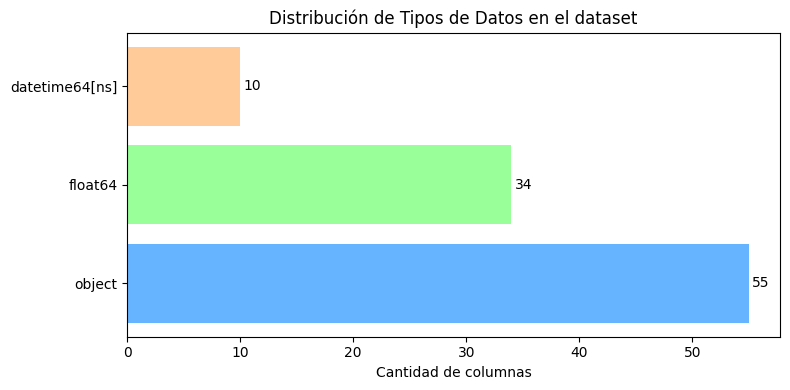

In [9]:
# Contar los tipos de datos en el DataFrame
dtype_counts = df.dtypes.value_counts()
dtype_df = pd.DataFrame({
    'Tipo de Dato': dtype_counts.index.astype(str),
    'Conteo': dtype_counts.values
})

# Colores personalizados
colors = ['#66b3ff', '#99ff99', '#ffcc99', '#ff9999']

# Crear gráfico de barras horizontales
plt.figure(figsize=(8, 4))
bars = plt.barh(dtype_df['Tipo de Dato'], dtype_df['Conteo'], color=colors)

# Añadir etiquetas sobre las barras
for bar, count in zip(bars, dtype_df['Conteo']):
    plt.text(count + 0.3, bar.get_y() + bar.get_height() / 2, str(count),
             va='center', ha='left', color='black')

# Título y estilo
plt.title('Distribución de Tipos de Datos en el dataset')
plt.xlabel('Cantidad de columnas')
plt.tight_layout()
plt.show()

El gráfico anterior permite observar que la mayoría de los atributos, un total de $55$, corresponden a datos categoricos. Además, se identifican $34$ atributos de tipo numerico, mientras que los $10$ restantes son de tipo fecha.

📊 ANÁLISIS DE VARIABLES OBJETIVO

🎯 Variable: MORTALIDAD GENERAL 
Distribución:
  NO: 908 casos (89.8%)
  SI: 102 casos (10.1%)

🎯 Variable: MORTALIDAD A 30 DÍAS 
Distribución:
  NO: 924 casos (91.4%)
  SI : 86 casos (8.5%)


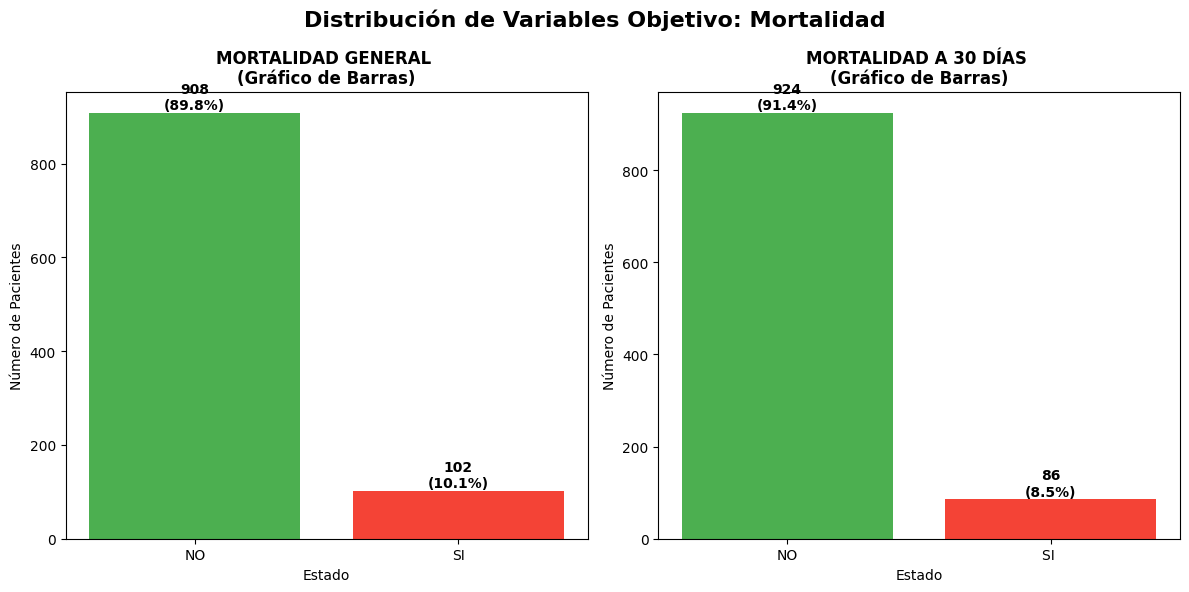


📋 ANÁLISIS CRUZADO DE VARIABLES OBJETIVO
Tabla de contingencia:
MORTALIDAD A 30 DÍAS    NO  SI   Total
MORTALIDAD GENERAL                    
NO                     908    0    908
SI                      16   86    102
Total                  924   86   1010

Tabla de porcentajes:
MORTALIDAD A 30 DÍAS      NO   SI 
MORTALIDAD GENERAL                
NO                     89.90  0.00
SI                      1.58  8.51

✅ Análisis de variables objetivo completado


In [10]:
# ANÁLISIS DE VARIABLES OBJETIVO: MORTALIDAD GENERAL Y MORTALIDAD A 30 DÍAS

print("=" * 70)
print("📊 ANÁLISIS DE VARIABLES OBJETIVO")
print("=" * 70)

# Verificar las variables objetivo
variables_objetivo = ['MORTALIDAD GENERAL ', 'MORTALIDAD A 30 DÍAS ']

# Contar los valores únicos para cada variable objetivo
for var in variables_objetivo:
    if var in df.columns:
        print(f"\n🎯 Variable: {var}")
        conteo = df[var].value_counts()
        print(f"Distribución:")
        for valor, cantidad in conteo.items():
            porcentaje = (cantidad / len(df)) * 100
            print(f"  {valor}: {cantidad} casos ({porcentaje:.1f}%)")
    else:
        print(f"⚠️ Variable '{var}' no encontrada en el DataFrame")

# Crear visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Distribución de Variables Objetivo: Mortalidad', fontsize=16, fontweight='bold')

# Colores para las gráficas
colors_bar = ['#4CAF50', '#F44336']  # Verde para NO, Rojo para SI

for i, var in enumerate(variables_objetivo):
    if var in df.columns:
        # Contar valores
        conteo = df[var].value_counts()

        # Ordenar para que 'NO' aparezca primero (supervivientes)
        if 'NO' in conteo.index and 'SI' in conteo.index:
            conteo = conteo.reindex(['NO', 'SI'])

        # Gráfico de barras (fila superior)
        ax_bar = axes[i]
        bars = ax_bar.bar(conteo.index, conteo.values, color=colors_bar)
        ax_bar.set_title(f'{var}\n(Gráfico de Barras)', fontweight='bold')
        ax_bar.set_ylabel('Número de Pacientes')
        ax_bar.set_xlabel('Estado')

        # Añadir valores sobre las barras
        for bar, valor in zip(bars, conteo.values):
            altura = bar.get_height()
            ax_bar.text(bar.get_x() + bar.get_width()/2., altura + 1,
                       f'{valor}\n({valor/len(df)*100:.1f}%)',
                       ha='center', va='bottom', fontweight='bold')


plt.tight_layout()
plt.show()

# Análisis cruzado de las dos variables objetivo
print(f"\n📋 ANÁLISIS CRUZADO DE VARIABLES OBJETIVO")
print("=" * 50)

if all(var in df.columns for var in variables_objetivo):
    # Crear tabla cruzada
    tabla_cruzada = pd.crosstab(df['MORTALIDAD GENERAL '],
                               df['MORTALIDAD A 30 DÍAS '],
                               margins=True, margins_name="Total")

    print("Tabla de contingencia:")
    print(tabla_cruzada)

    # Tabla de porcentajes
    print(f"\nTabla de porcentajes:")
    tabla_porcentajes = pd.crosstab(df['MORTALIDAD GENERAL '],
                                   df['MORTALIDAD A 30 DÍAS '],
                                   normalize='all') * 100
    print(tabla_porcentajes.round(2))

    # Mortalidad General
    mg_si = (df['MORTALIDAD GENERAL '] == 'SI').sum()
    mg_porcentaje = (mg_si / len(df)) * 100

    # Mortalidad a 30 días
    m30_si = (df['MORTALIDAD A 30 DÍAS '] == 'SI').sum()
    m30_porcentaje = (m30_si / len(df)) * 100

    # Concordancia entre las dos variables
    concordancia = (df['MORTALIDAD GENERAL '] == df['MORTALIDAD A 30 DÍAS ']).sum()
    concordancia_porcentaje = (concordancia / len(df)) * 100

else:
    print("⚠️ No se pueden realizar análisis cruzados: faltan variables objetivo")

print(f"\n✅ Análisis de variables objetivo completado")

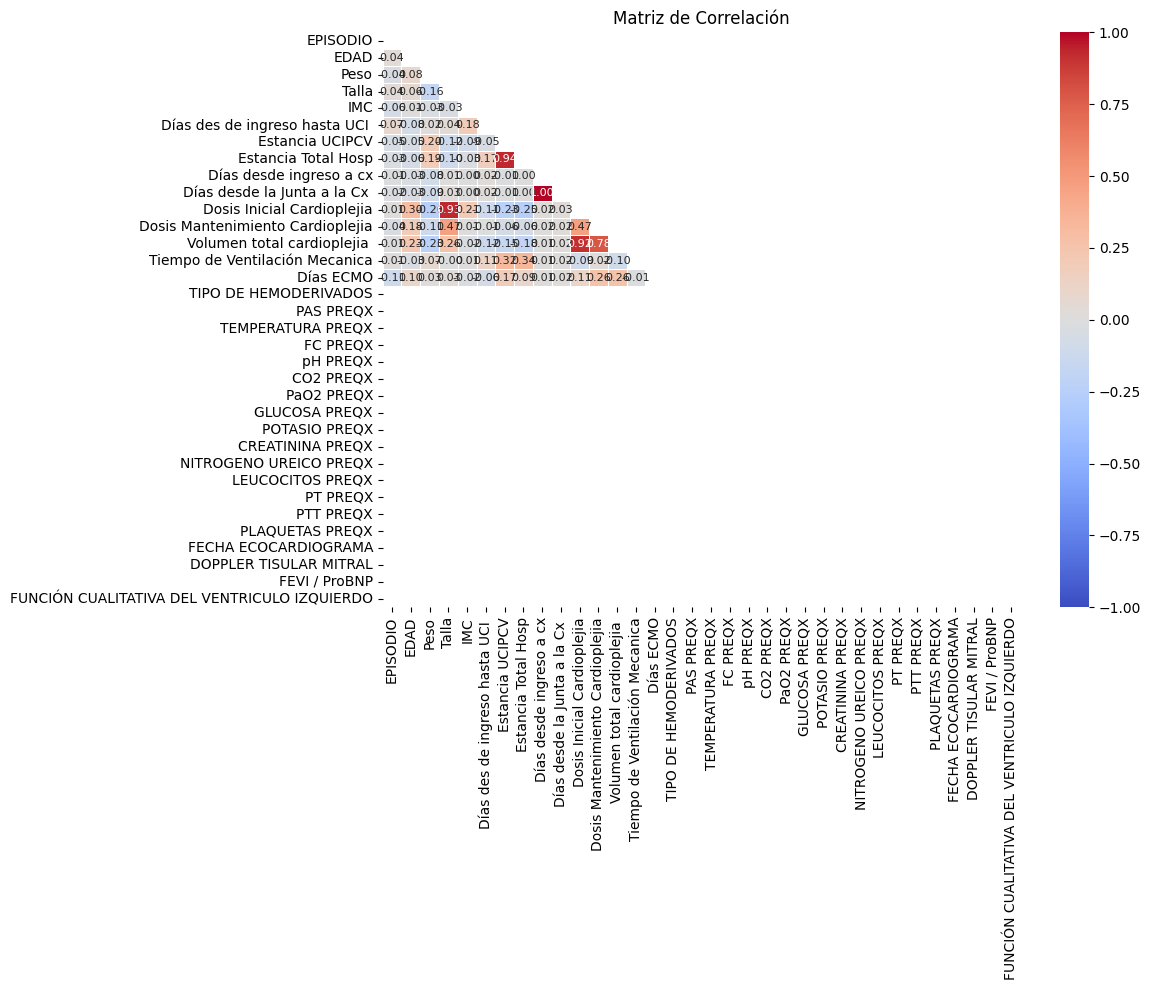

In [11]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

corr_matrix = df[numerical_columns].corr(method='pearson')

# Máscara para la mitad superior (opcional, para evitar duplicados)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Visualizamos la matriz de correlación como un mapa de calor (heatmap) con coeficientes
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,                # quitar si quieres ver toda la matriz
    cmap='coolwarm',
    vmin=-1, vmax=1, center=0,
    annot=True,               # muestra los coeficientes
    fmt='.2f',                # formato de los coeficientes
    annot_kws={'fontsize': 8},
    cbar=True,
    linewidths=0.5
)
plt.title("Matriz de Correlación")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()